In [7]:


# Ноутбук для публичной версии кода, без АПИ-ключа
import os
API_KEY = os.getenv("OPENWEATHER_API_KEY")
if not API_KEY:
    raise ValueError("Set OPENWEATHER_API_KEY in environment before running.")

In [8]:
import pandas as pd
import numpy as np

# Реальные средние температуры (примерные данные) для городов по сезонам
seasonal_temperatures = {
    "New York": {"winter": 0, "spring": 10, "summer": 25, "autumn": 15},
    "London": {"winter": 5, "spring": 11, "summer": 18, "autumn": 12},
    "Paris": {"winter": 4, "spring": 12, "summer": 20, "autumn": 13},
    "Tokyo": {"winter": 6, "spring": 15, "summer": 27, "autumn": 18},
    "Moscow": {"winter": -10, "spring": 5, "summer": 18, "autumn": 8},
    "Sydney": {"winter": 12, "spring": 18, "summer": 25, "autumn": 20},
    "Berlin": {"winter": 0, "spring": 10, "summer": 20, "autumn": 11},
    "Beijing": {"winter": -2, "spring": 13, "summer": 27, "autumn": 16},
    "Rio de Janeiro": {"winter": 20, "spring": 25, "summer": 30, "autumn": 25},
    "Dubai": {"winter": 20, "spring": 30, "summer": 40, "autumn": 30},
    "Los Angeles": {"winter": 15, "spring": 18, "summer": 25, "autumn": 20},
    "Singapore": {"winter": 27, "spring": 28, "summer": 28, "autumn": 27},
    "Mumbai": {"winter": 25, "spring": 30, "summer": 35, "autumn": 30},
    "Cairo": {"winter": 15, "spring": 25, "summer": 35, "autumn": 25},
    "Mexico City": {"winter": 12, "spring": 18, "summer": 20, "autumn": 15},
}

# Сопоставление месяцев с сезонами
month_to_season = {12: "winter", 1: "winter", 2: "winter",
                   3: "spring", 4: "spring", 5: "spring",
                   6: "summer", 7: "summer", 8: "summer",
                   9: "autumn", 10: "autumn", 11: "autumn"}

# Генерация данных о температуре
def generate_realistic_temperature_data(cities, num_years=10):
    dates = pd.date_range(start="2010-01-01", periods=365 * num_years, freq="D")
    data = []

    for city in cities:
        for date in dates:
            season = month_to_season[date.month]
            mean_temp = seasonal_temperatures[city][season]
            # Добавляем случайное отклонение
            temperature = np.random.normal(loc=mean_temp, scale=5)
            data.append({"city": city, "timestamp": date, "temperature": temperature})

    df = pd.DataFrame(data)
    df['season'] = df['timestamp'].dt.month.map(lambda x: month_to_season[x])
    return df

# Генерация данных
data = generate_realistic_temperature_data(list(seasonal_temperatures.keys()))
data.to_csv('temperature_data.csv', index=False)


In [9]:
from google.colab import files
files.download('temperature_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import os
import time
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [11]:

CSV_PATH = "temperature_data.csv"
WINDOW = 30

df = pd.read_csv(str(CSV_PATH), parse_dates=["timestamp"])
df = df.sort_values(["city", "timestamp"]).reset_index(drop=True)

# найдем скользяшее среднее и стандартное отклон по 30 дням
df["rolling_mean_30d"] = (df.groupby("city")["temperature"].rolling(window=WINDOW, min_periods=WINDOW).mean().reset_index(level=0, drop=True))

df["rolling_std_30d"] = (df.groupby("city")["temperature"].rolling(window=WINDOW, min_periods=WINDOW).std(ddof=0).reset_index(level=0, drop=True))

df.head(), df.shape

(      city  timestamp  temperature  season  rolling_mean_30d  rolling_std_30d
 0  Beijing 2010-01-01    -8.724623  winter               NaN              NaN
 1  Beijing 2010-01-02    -5.602554  winter               NaN              NaN
 2  Beijing 2010-01-03     6.362854  winter               NaN              NaN
 3  Beijing 2010-01-04     1.137452  winter               NaN              NaN
 4  Beijing 2010-01-05     4.460452  winter               NaN              NaN,
 (54750, 6))

In [12]:
# теперь нужно найти среднюю температуру и стандартное отклонение для каждого сезона в каждом городе
df["season_mean"] = df.groupby(["city", "season"])["temperature"].transform("mean")
df["season_std"]  = df.groupby(["city", "season"])["temperature"].transform(lambda s: s.std(ddof=0))

df[["city","season","temperature","season_mean","season_std"]].head()

# определим границы в 2 стандартотклона (причем именно стд для каждого сезона), за пределами которых у нас будут аномалии
df["low_lim"] = df["season_mean"] - 2 * df["season_std"]
df["hi_lim"] = df["season_mean"] + 2 * df["season_std"]

# посмотрим, где имеются аномалии, создадим спец столбец
df["anomaly"] = ((df["temperature"] < df["low_lim"]) + (df["temperature"] > df["hi_lim"])).astype(bool)

df["anomaly"].value_counts()

,count
anomaly,
False,52211
True,2539


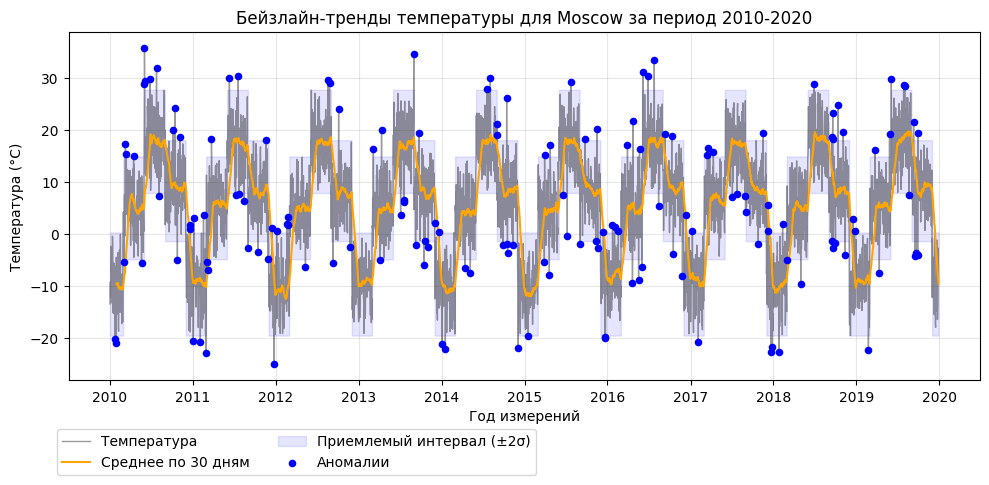

In [13]:

# рисуем график

target_city = "Moscow"
selected = df[df["city"] == target_city].sort_values("timestamp")
#выбирает данные только для Мск и сортирует их по дате.
anomaly_vals = selected[selected["anomaly"]] # сразу определим отдельно анормальные точки

plt.figure(figsize=(10, 5))
# рисуем посуточную линию Т,
 # (температура по дням, сформированная на основе средних значений по сезонам + рандомные отклонения по нормальному распределению)
plt.plot(selected["timestamp"], selected["temperature"], label="Температура", alpha=0.4, color="black", linewidth=1)

# теперь скользящее среднее
plt.plot(selected["timestamp"], selected["rolling_mean_30d"], label=f"Среднее по {WINDOW} дням", color="orange", linewidth=1.5)

# интервал в два стандартотклона от среднего, за пределом которого все температуры - аномальны
plt.fill_between(selected["timestamp"], selected["low_lim"], selected["hi_lim"],
                 color="blue", alpha=0.1, label="Приемлемый интервал (±2σ)")

# точки с аномалиями
plt.scatter(anomaly_vals["timestamp"], anomaly_vals["temperature"], color="blue", label="Аномалии", s=20, zorder=5)

year_min = selected["timestamp"].dt.year.min()
year_max = selected["timestamp"].dt.year.max()

plt.title(f"Бейзлайн-тренды температуры для {target_city} за период 2010-2020")
plt.xlabel("Год измерений")
plt.ylabel("Температура (°C)")
plt.legend(loc="upper center", bbox_to_anchor=(0.25, -0.12), ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("moscow_temp_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

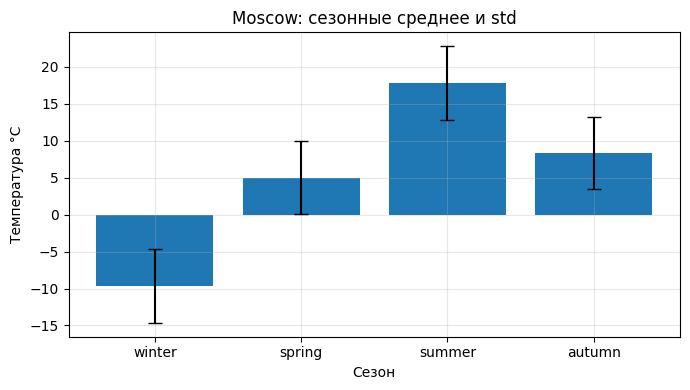

In [14]:
# дополнительные графики
# сезонные данные
st = (df[df["city"] == target_city].groupby("season")[["season_mean", "season_std"]].first().reset_index())

seasons = ["winter", "spring", "summer", "autumn"]
st["season"] = pd.Categorical(st["season"], categories=seasons, ordered=True)
st = st.sort_values("season")
x = np.arange(len(st))

plt.figure(figsize=(7, 4))
plt.bar(x, st["season_mean"].values, yerr=st["season_std"].values, capsize=5)
plt.xticks(x, st["season"].astype(str).values)
plt.title(f"{target_city}: сезонные среднее и std")
plt.xlabel("Сезон")
plt.ylabel("Температура °C")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


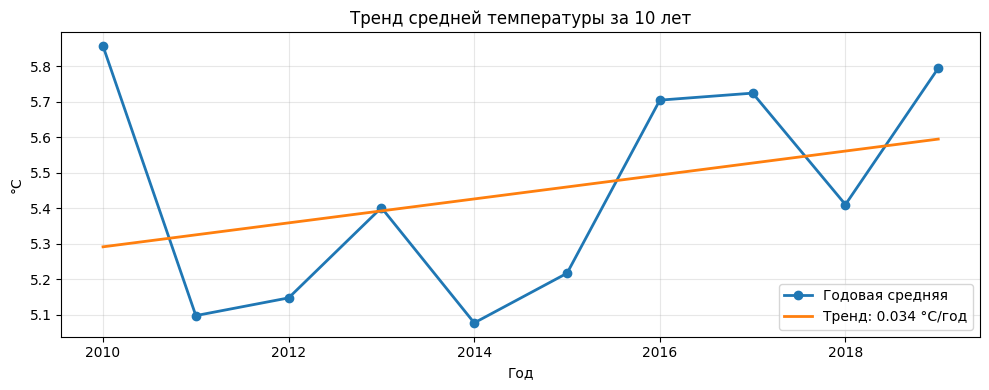

In [15]:
# тренд более общий

def plot_trend(df, target_city="Moscow", save_path=None):
    g = df[df["city"] == target_city].copy()
    g["year"] = g["timestamp"].dt.year

    yearly = (g.groupby("year")["temperature"].mean().reset_index(name="temp_year_mean").sort_values("year"))

    x = yearly["year"].to_numpy(dtype=float)
    y = yearly["temp_year_mean"].to_numpy(dtype=float)

    a, b = np.polyfit(x, y, 1)
    function = a * x + b

    plt.figure(figsize=(10, 4))
    plt.plot(yearly["year"], yearly["temp_year_mean"], marker="o", linewidth=2, label="Годовая средняя")
    plt.plot(yearly["year"], function, linewidth=2, label=f"Тренд: {a:.3f} °C/год")

    plt.title(f"Тренд средней температуры за 10 лет")
    plt.xlabel("Год")
    plt.ylabel("°C")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_trend(df, "Moscow")

In [16]:
# приступим к проверке разных способов анализировать датасет: с параллельностью и без нее
# для начала определим общий пайплайн обработки данных для каждого города

df_one = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df_etalon = df_one.sort_values(["city", "timestamp"]).reset_index(drop=True)

cities_list = df_etalon["city"].unique().tolist()

def processing_pipe(df: pd.DataFrame): # повторяем те же этапы
    df = df.sort_values("timestamp").copy()

    df["rolling_mean_30d"] = df["temperature"].rolling(window=WINDOW, min_periods=WINDOW).mean()
    df["rolling_std_30d"]  = df["temperature"].rolling(window=WINDOW, min_periods=WINDOW).std(ddof=0)

    season_mean = df.groupby("season")["temperature"].transform("mean")
    season_std  = df.groupby("season")["temperature"].transform(lambda s: s.std(ddof=0))
    df["season_mean"] = season_mean
    df["season_std"]  = season_std

    df["low_lim"] = df["season_mean"] - 2 * df["season_std"]
    df["hi_lim"]  = df["season_mean"] + 2 * df["season_std"]

    df["anomaly"] = np.logical_or(df["temperature"] < df["low_lim"], df["temperature"] > df["hi_lim"])

    return df

# сразу создаем группы, категории по городам
categories = [df_etalon[df_etalon["city"] == i].copy() for i in cities_list]


In [44]:
# без параллельности: применяем пайплайн из функций к каждой группе городов

def baseline(grps):
    output = [processing_pipe(i) for i in grps]
    return pd.concat(output, ignore_index=True)
start = time.time()
baseline(categories)
end = time.time()
print(end - start)

0.16245532035827637


In [55]:
# ThreadPoolExecutor: многопоточность. Есть ограничения на скорость в виде gil, overhead при вычислениях

def run_threads(grps, workers=8):
    workers = workers or os.cpu_count()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        output = list(ex.map(processing_pipe, grps))
    return pd.concat(output, ignore_index=True)

start = time.time()
run_threads(categories)
end = time.time()
print(end - start)

0.19890856742858887


In [60]:
# ProcessPoolExecutor: разные процессы, избегает gil

def run_processes(grps, workers=8): # в дальнейшем можно было бы посмотреть статистику скорости в зависимости от количества воркеров
    workers = workers or os.cpu_count()
    ctx = mp.get_context("fork")
    with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as ex:
        output = list(ex.map(processing_pipe, grps))
    return pd.concat(output, ignore_index=True)

start = time.time()
run_processes(categories)
end = time.time()
print(end - start)

0.3742828369140625


In [20]:
# попробуем с modin

!pip -q install "modin[ray]" ray


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.4.4 requires click!=8.2.*,>=4.0, but you have click 8.2.1 which is incompatible.


In [21]:
import ray
ray.init(ignore_reinit_error=True)

import modin.pandas as mpd

2025-12-20 01:25:59,727	INFO worker.py:2023 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [22]:
dfm = mpd.read_csv(CSV_PATH, parse_dates=["timestamp"])
dfm = dfm.sort_values(["city", "timestamp"]).reset_index(drop=True)

def modin_pipeline(dfm):
    dfm = dfm.copy()

    dfm["rolling_mean_30d"] = (dfm.groupby("city")["temperature"].rolling(window=WINDOW, min_periods=WINDOW)
           .mean().reset_index(level=0, drop=True))

    dfm["rolling_std_30d"] = (dfm.groupby("city")["temperature"].rolling(window=WINDOW, min_periods=WINDOW)
           .std(ddof=0).reset_index(level=0, drop=True))

    dfm["season_mean"] = dfm.groupby(["city", "season"])["temperature"].transform("mean")
    dfm["season_std"]  = dfm.groupby(["city", "season"])["temperature"].transform(lambda s: s.std(ddof=0))

    dfm["low_lim"] = dfm["season_mean"] - 2 * dfm["season_std"]
    dfm["hi_lim"]  = dfm["season_mean"] + 2 * dfm["season_std"]

    dfm["anomaly"] = np.logical_or(dfm["temperature"] < dfm["low_lim"], dfm["temperature"] > dfm["hi_lim"])
    return dfm

start = time.time()
output = modin_pipeline(dfm)
fin = output._to_pandas()
end = time.time()
print(end - start)
fin.head()

(raylet) [2025-12-20 01:26:28,739 E 701 701] (raylet) main.cc:979: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
Please refer to https://modin.readthedocs.io/en/stable/supported_apis/defaulting_to_pandas.html for explanation.


4.25627589225769


,city,timestamp,temperature,season,rolling_mean_30d,rolling_std_30d,season_mean,season_std,low_lim,hi_lim,anomaly
0,Beijing,2010-01-01,-8.724623,winter,NaN,NaN,-2.143614,5.073182,-12.289977,8.002749,False
1,Beijing,2010-01-02,-5.602554,winter,NaN,NaN,-2.143614,5.073182,-12.289977,8.002749,False
2,Beijing,2010-01-03,6.362854,winter,NaN,NaN,-2.143614,5.073182,-12.289977,8.002749,False
3,Beijing,2010-01-04,1.137452,winter,NaN,NaN,-2.143614,5.073182,-12.289977,8.002749,False
4,Beijing,2010-01-05,4.460452,winter,NaN,NaN,-2.143614,5.073182,-12.289977,8.002749,False


In [62]:
# векторизованный pandas

def run_vectorized(df):
    df = df.copy()

    df["rolling_mean_30d"] = (
        df.groupby("city")["temperature"]
          .rolling(window=WINDOW, min_periods=WINDOW)
          .mean()
          .reset_index(level=0, drop=True)
    )

    df["rolling_std_30d"] = (
        df.groupby("city")["temperature"]
          .rolling(window=WINDOW, min_periods=WINDOW)
          .std(ddof=0)
          .reset_index(level=0, drop=True)
    )

    df["season_mean"] = df.groupby(["city", "season"])["temperature"].transform("mean")
    df["season_std"]  = df.groupby(["city", "season"])["temperature"].transform(lambda s: s.std(ddof=0))

    df["low_lim"] = df["season_mean"] - 2 * df["season_std"]
    df["hi_lim"]  = df["season_mean"] + 2 * df["season_std"]

    df["anomaly"] = np.logical_or(df["temperature"] < df["low_lim"],
                                  df["temperature"] > df["hi_lim"])
    return df

start = time.time()
run_vectorized(df_etalon)
end = time.time()
print(end - start)

0.07826828956604004


In [24]:
# ВЫВОДЫ: бейзлайн (просто пробегаться по строчкам) работает довольно хорошо, быстрее, чем при многопоточности и многопроцессности
# Это может быть связано с небольшим размером датасета + временные затраты на распределение задач между воркерами
# modin работает особенно долго: в данном случае этот метод неэффективен.
# Сильно выигрывает векторизованный пандас.
# многопоточность работает немного быстрее, чем бейзлайн. ProcessPoolExecutor работает дольше.

# Почему векторизованный pandas самый быстрый: вычисления происходят над датафреймом на С, а не Python,
# нет распаковки/сборки списков датафреймов, нет concat, нет сериализации

# Из-за gil почти нет разницы между обычными циклами и многопоточностью. ProcessPoolExecutor создает параллельные вычисления,
# но из-за сериализации, необходимости копирования информации для получения данных и возвращения результата, реальное время выполнения дольше
# Для эффективности ProcessPool нужны более сложные и объемные по операциям задачи

# modin только ускоряет вычисления путем параллельного выполнения партиций воркерами. Тут их не так много.
# Но накладные расходы остаются: разбиение на партиции, запуск Ray итд

In [25]:
# ЧАСТЬ ВТОРАЯ: API

In [26]:
import requests

def get_current_temp(city, country_code = None):
    # создаем запрос для апи, делаем словарь с данными о городе (ждем 1 результат) и ключом, ссылку на сайт куда пойдет запрос
    # сначала мы хотим найти город и его геопозицию
    url = "https://api.openweathermap.org/geo/1.0/direct"
    city_info = {"q": f"{city},{country_code}" if country_code else city, "limit": 1, "appid": API_KEY}
    #затем отправлякм сам http get запрос с данными о городе и временем, в течение которого ждем ответ
    geo_request = requests.get(url, params=city_info, timeout=10)
    geo_request.raise_for_status() # увидеть ошибку если что-то не так
    data = geo_request.json() # json формат ответа переводим в словарь
    if not data:
      raise ValueError("нет результатов")

    # определяем широту и долготу
    name = data[0].get("name", city)
    lat = data[0]["lat"]
    lon = data[0]["lon"]

    # теперь ищем в другом окне погоду для выявленной локации
    weather_url = "https://api.openweathermap.org/data/2.5/weather"
    weather_params = {"lat": lat, "lon": lon, "appid": API_KEY, "units": "metric"}

    current_weather = requests.get(weather_url, params=weather_params, timeout=10)
    current_weather.raise_for_status()
    w_json = current_weather.json()

    temp = w_json["main"]["temp"]
    return temp

In [27]:
temp = get_current_temp("Moscow", country_code="RU")
temp

-1.12

In [28]:
start = time.time()
temp = get_current_temp("Paris", country_code="FR")
temp
end = time.time()
print(end - start)
print(temp)

0.4576706886291504
7.31


In [29]:
# теперь сравниваем текущую температуру со среднесезонным значением и диапазоном в два стандартных отклонения
# для выявления аномалий

# сначала определим текущее время и сезон
import datetime as dt

current_season = month_to_season[dt.datetime.now().month]

# выявление аномалий
def is_anomaly(city, df, temp, country_code=None):
    # берем текущую температуру из предыдущей функции

    # достаем исторические данные из предыдущей части
    row = df[(df["city"] == city) & (df["season"] == current_season)].iloc[0]

    low_lim = float(row["season_mean"]) - 2 * float(row["season_std"])
    hi_lim = float(row["season_mean"]) + 2 * float(row["season_std"])

    if temp < low_lim or temp > hi_lim:
        return True
    else:
        return False
if is_anomaly("Moscow", df=df, temp=temp, country_code="RU"):
    print("Аномалия")
else:
    print("OK")

Аномалия


In [30]:
cities = {"Dubai": "AE", "Berlin": "DE", "Cairo": "EG", "London": "GB", "Paris": "FR"}

temps = {}
is_anomaly_dict = {}

for city, code in cities.items():
    temp = get_current_temp(city, country_code=code)
    temps[city] = temp
    is_anomaly_dict[city] = is_anomaly(city, df, temp, country_code=code)

temps, is_anomaly_dict

({'Dubai': 14.02,
  'Berlin': 8.58,
  'Cairo': 11.33,
  'London': 4.89,
  'Paris': 7.31},
 {'Dubai': False,
  'Berlin': False,
  'Cairo': False,
  'London': False,
  'Paris': False})

In [31]:
!pip -q install aiohttp

In [32]:
import asyncio
import aiohttp

# сделаем функцию асинхронной и протестируем время
# функция написана при помощи ChatGPT на основе синхронной функции выше

async def get_current_temp_async_session(session, city, country_code=None):
    url = "https://api.openweathermap.org/geo/1.0/direct"
    city_info = {"q": f"{city},{country_code}" if country_code else city, "limit": 1, "appid": API_KEY}

    async with session.get(url, params=city_info, timeout=10) as r:
        r.raise_for_status()
        data = await r.json()
    if not data:
        raise ValueError("нет результатов")

    lat = data[0]["lat"]
    lon = data[0]["lon"]

    weather_url = "https://api.openweathermap.org/data/2.5/weather"
    weather_params = {"lat": lat, "lon": lon, "appid": API_KEY, "units": "metric"}

    async with session.get(weather_url, params=weather_params, timeout=10) as r:
        r.raise_for_status()
        w_json = await r.json()

    return w_json["main"]["temp"]

async def get_many_temps(cities_dict):
    async with aiohttp.ClientSession() as session:
        tasks = [get_current_temp_async_session(session, city, code) for city, code in cities_dict.items()]
        results = await asyncio.gather(*tasks, return_exceptions=True)
    return dict(zip(cities_dict.keys(), results))

In [33]:
# асинхронное выполнение по нескольким городам

start = time.time()
cities = {"Dubai":"AE", "Berlin":"DE", "Cairo":"EG", "Beijing":"CN", "Moscow":"RU"}
temps = await get_many_temps(cities)
end = time.time()
print(end - start)
print(temps)

0.3687601089477539
{'Dubai': 14.02, 'Berlin': 8.58, 'Cairo': 11.33, 'Beijing': 0.94, 'Moscow': -1.12}


In [34]:
# проделаем то же самое с базовой синхронной функцией, просто через цикл for
start = time.time()
cities = {"Dubai":"AE", "Berlin":"DE", "Cairo":"EG", "Beijing":"CN", "Moscow":"RU"}

temps_sync = {}
for city, code in cities.items():
    temps_sync[city] = get_current_temp(city, country_code=code)
end = time.time()
print(end - start)
print(temps_sync)


1.457143783569336
{'Dubai': 14.02, 'Berlin': 8.58, 'Cairo': 11.33, 'Beijing': 0.94, 'Moscow': -1.12}


In [35]:
# ВЫВОДЫ: асинхронный подход явно предпочтительнее, так как запросы по апи на несколько городов происходят одновременно
# время ожидания равно не сумме ожидания по каждому городу, а времени выполнения самого длинного запроса.

In [36]:
# ЧАСТЬ ТРЕТЬЯ: СТРИМЛИТ

In [37]:
# код файла
# создан на базе скопированных из ноутбука выше функций, другие функции и блоки были написаны при помощи Gemini-3 Pro
# с собственными поправками.

import streamlit as st
import pandas as pd
import numpy as np
import requests
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

# заголовок
st.set_page_config(page_title="Анализ Температурных Данных", layout="wide")

st.title("🌦️ Текущая погода и Исторические тренды по городам")

# функции

def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

def load_data(uploaded_file): # чтение файла, создание столбца с текущим временем и сезоном
    if uploaded_file is not None:
        try:
            df = pd.read_csv(uploaded_file)
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
                if 'season' not in df.columns:
                    df['season'] = df['timestamp'].dt.month.map(get_season)
            return df
        except Exception as e:
            st.error(f"Ошибка при чтении файла: {e}")
            return None
    return None

# повторение того, что в ноутбуке: статистика температуры по сезонам, определение интервала для аномалий
def calculate_stats(df, city):
    city_data = df[df['city'] == city].copy()

    # для выбранного города выведем основную базовую информацию
    stats = city_data['temperature'].describe()

    # Сезонные профили (как в ноутбуке)
    seasonal_stats = city_data.groupby('season')['temperature'].agg(['mean', 'std']).reset_index()

    # Аномалии: вычисляем границы для каждой записи на основе сезона по каждому городу
    city_data = city_data.merge(seasonal_stats, on='season', suffixes=('', '_season'))

    city_data['lower_bound'] = city_data['mean'] - 2 * city_data['std']
    city_data['upper_bound'] = city_data['mean'] + 2 * city_data['std']

    city_data['is_anomaly'] = (city_data['temperature'] < city_data['lower_bound']) | \
                              (city_data['temperature'] > city_data['upper_bound'])

    return city_data, stats, seasonal_stats

# повторение функции из тренировочного ноутбука + проверка АПИ
def get_current_weather(city, api_key):
    url = "http://api.openweathermap.org/data/2.5/weather"
    params = {"q": city, "appid": api_key, "units": "metric"}
    response = requests.get(url, params=params)

    if response.status_code == 401:
        return {"cod": 401, "message": "Invalid API key. Please see https://openweathermap.org/faq#error401 for more info."}
    elif response.status_code != 200:
        return {"cod": response.status_code, "message": f"Error: {response.reason}"}

    return response.json()

# сбоку будет находиться форма для загрузки csv файла и ввода АПИ-ключа
st.sidebar.header("Настройки")

uploaded_file = st.sidebar.file_uploader("Загрузите CSV-файл с историческими данными", type="csv")

api_key = st.sidebar.text_input("Введите API-ключ OpenWeatherMap", type="password")


if uploaded_file is not None:
    df = load_data(uploaded_file)

    if df is not None:
        # Выбор города из выпадающего списка, затем статистика по нему
        cities = df['city'].unique()
        selected_city = st.selectbox("Выберите город", cities)

        city_df, des_stats, seasonal_stats = calculate_stats(df, selected_city)

        st.subheader(f"📊 Исторические данные для города: {selected_city}")

        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Средняя темп.", f"{des_stats['mean']:.2f} °C")
        col2.metric("Мин. темп.", f"{des_stats['min']:.2f} °C")
        col3.metric("Макс. темп.", f"{des_stats['max']:.2f} °C")
        col4.metric("Станд. откл.", f"{des_stats['std']:.2f} °C")

        st.subheader("📈 История температуры за 10 лет")

        # используем plotly, в отличие от ноутбука
        fig = go.Figure()

        # температура посуточная
        fig.add_trace(go.Scatter(
            x=city_df['timestamp'],
            y=city_df['temperature'],
            mode='lines',
            name='Температура',
            line=dict(color='blue', width=1),
            opacity=0.6
        ))

        # обозначение красным цветом точек аномалий
        anomalies = city_df[city_df['is_anomaly']]
        fig.add_trace(go.Scatter(
            x=anomalies['timestamp'],
            y=anomalies['temperature'],
            mode='markers',
            name='Аномалии',
            marker=dict(color='red', size=5, symbol='star')
        ))

        # скользящее среднее - основная линия
        city_df['rolling_mean'] = city_df['temperature'].rolling(window=30).mean()
        fig.add_trace(go.Scatter(
            x=city_df['timestamp'],
            y=city_df['rolling_mean'],
            mode='lines',
            name='Средняя Т, за 30сут',
            line=dict(color='orange', width=2)
        ))

        fig.update_layout(
            title=f"{selected_city}: температурный тренд 2010-2020",
            xaxis_title="Год измерений",
            yaxis_title="Температура (°C)",
            hovermode="x unified"
        )
        st.plotly_chart(fig, use_container_width=True)

        # Профили температур (среднее и стандартотклон) по сезонам
        st.subheader("🍂 Сезонные профили")

        seasonal_display = seasonal_stats.copy()
        seasonal_display.columns = ['Сезон', 'Средняя температура', 'Стандартное отклонение']

        # Отображение таблицы и графика рядом
        scol1, scol2 = st.columns([1, 2])

        with scol1:
            st.write("Статистика по сезонам:")
            st.dataframe(seasonal_display.style.format("{:.2f}", subset=['Средняя температура', 'Стандартное отклонение']))

        with scol2:
            fig_season = px.bar(
                seasonal_stats,
                x='season',
                y='mean',
                error_y='std',
                title="Средняя температура по сезонам (с ошибкой std)",
                labels={'mean': 'Средняя температура (°C)', 'season': 'Сезон'},
                color='season'
            )
            st.plotly_chart(fig_season, use_container_width=True)

        # вывод текущей температуры для города
        st.divider()
        st.subheader(f"🌍 Текущая погода: {selected_city}")

        if api_key:
            current_weather = get_current_weather(selected_city, api_key)
            # проверка ключа
            if "cod" in current_weather and current_weather["cod"] == 401:
                st.error(f"Ошибка API: {current_weather['message']}")
            elif "cod" in current_weather and current_weather["cod"] != 200:
                st.error(f"Не удалось получить погоду: {current_weather.get('message', 'Unknown error')}")
            else:
                curr_temp = current_weather['main']['temp']
                curr_humidity = current_weather['main']['humidity']
                curr_desc = current_weather['weather'][0]['description']

                # Как в ноутбуке, определеним текущий сезон
                current_month = datetime.now().month
                current_season = get_season(current_month)

                # Проверка на аномалию
                season_row = seasonal_stats[seasonal_stats['season'] == current_season]
                if not season_row.empty:
                    mean_temp = season_row['mean'].values[0]
                    std_temp = season_row['std'].values[0]

                    lower_normal = mean_temp - 2 * std_temp
                    upper_normal = mean_temp + 2 * std_temp

                    is_normal = lower_normal <= curr_temp <= upper_normal

                    # Визуализация текущей погоды
                    wc1, wc2 = st.columns(2)
                    with wc1:
                        st.metric("Текущая температура", f"{curr_temp} °C", delta=None)
                        st.write(f"Погодные условия: **{curr_desc}**")
                        st.write(f"Влажность: **{curr_humidity}%**")

                    with wc2:
                        st.write(f"Текущий сезон: **{current_season}**")
                        st.write(f"Исторический диапазон (норма): **{lower_normal:.1f} °C ... {upper_normal:.1f} °C**")

                        if is_normal:
                            st.success("✅ Текущая температура в пределах нормы для сезона.")
                        else:
                            st.warning("⚠️ Текущая температура аномальна для этого сезона!")
                else:
                    st.info("Недостаточно исторических данных для анализа текущего сезона.")
        else:
            st.info("Введите API-ключ OpenWeatherMap в меню слева, чтобы увидеть текущую погоду.")

    else:
        st.warning("Пожалуйста, убедитесь, что ваш CSV файл содержит необходимые колонки (city, timestamp, temperature).")
else:
    st.info("Пожалуйста, загрузите CSV файл с историческими данными в меню слева для начала работы.")
    st.markdown("""
    **Ожидаемый формат файла:**
    * `city`: Название города
    * `timestamp`: Дата (YYYY-MM-DD)
    * `temperature`: Температура
    * `season`: Сезон (опционально, вычисляется автоматически)
    """)

ModuleNotFoundError: No module named 'streamlit'